In [1]:
from typing import TypedDict, Annotated
from langchain_core.messages import (HumanMessage, AIMessage, ToolMessage )
from langchain_core.tools import tool
from langgraph.graph import ( StateGraph, START, END)
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq

In [2]:
import os
from dotenv import load_dotenv

# Load API key from backend/.env
dotenv_path = os.path.abspath("../../../../.env")
load_dotenv(dotenv_path)

if not os.environ.get("GROQ_API_KEY"):
    print("Warning: GROQ_API_KEY not found in backend/.env")
else:
    print("GROQ_API_KEY loaded successfully.")

GROQ_API_KEY loaded successfully.


In [3]:

class Contradiction(TypedDict):
    """A contradiction detected between sources."""
    product_slug: str
    field: str
    existing_value: str
    new_value: str
    existing_source: str
    new_source: str
    resolution: str  # pending | resolved
    preferred_source: str

In [4]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [5]:
from typing import TypedDict, Literal, Any
from datetime import datetime

class DBSource(TypedDict):
    """Source item fetched from DB containing category and CSV data."""
    category: str
    data: str  # CSV formatted data string
    format: str  # e.g. "csv"

In [6]:
#  Review State
class ExtractedReview(TypedDict):
    """A review record extracted from a CSV."""
    product_slug: str
    product_name: str
    rating: float
    title: str
    body: str
    reviewer: str
    date: str
    source_file: str

class ReviewSynthesis(TypedDict):
    """Synthesized review data for a product."""
    product_slug: str
    product_name: str
    avg_rating: float
    total_reviews: int
    sentiment_summary: str
    top_pros: list[str]
    top_cons: list[str]
    best_reviews: list[dict[str, str]]    


In [7]:
class WikiPage(TypedDict):
    """Represents a wiki page to create or update."""
    slug: str
    title: str
    page_type: str  # product | category | review | insight | promotion | specialty | popular
    section: str  # knowledge | marketing
    file_path: str
    content: str
    sources: list[str]
    links: list[str]


In [8]:
# Extracted product detail 
class ExtractedProduct(TypedDict):
    """A product entity extracted from a source."""
    name: str
    slug: str  # canonical ID, e.g. "iphone-15"
    brand: str
    category: str
    price: str
    currency: str
    description: str
    specifications: dict[str, str]
    source_file: str
    raw_data: dict[str, Any]

In [9]:
class WikiState(TypedDict):
    """
    Central state that flows through all LangGraph nodes.

    Both 'knowledge' and 'marketing' sections use this same state.
    The `wiki_section` field controls which sub-directory is targeted.
    """

    # Identity
    merchant_id: str
    wiki_section: str  # "knowledge" | "marketing"

    wiki_base_path: str  # root of merchant_knowledge/

    # DB Data Collection 
    collected_data: list[dict[str, Any]]
    classified_sources: dict[str, list[DBSource]]  # category -> list of DBSource (CSV data)

    extracted_products: list[ExtractedProduct]

    extracted_reviews: list[ExtractedReview]
    review_syntheses: list[ReviewSynthesis]

     # Wiki maintenance 
    entities: list[dict[str, Any]]
    existing_pages: dict[str, str]

    pages_to_update: list[WikiPage]
    contradictions: list[Contradiction]

In [10]:
def fetch_db_data(merchant_id: str, section: str) -> list[dict[str, Any]]:
    """
    Database call that fetches N (e.g. 25) raw data rows for a merchant.
    Each row contains the payload data along with its category field 
    (e.g., 'catalog', 'review', 'document', 'promotion').
    """
    # Example SQL / ORM Query:
    # SELECT * FROM merchant_records WHERE merchant_id = :merchant_id AND section = :section
    return []

In [11]:
def collect_data(state: WikiState) -> dict:
    """
    Collects datasets from the DB call (category + CSV data), 
    and directly builds `classified_sources` mapped by category.
    """
    merchant_id = state.get("merchant_id")
    section = state.get("wiki_section", "knowledge")
    if not merchant_id:
        return {
            "collected_data": [],
            "classified_sources": {},
            "status": "failed",
            "error": "Merchant ID is missing from state.",
        }
    try:
        # Fetch category (str) and CSV data directly from DB call
        db_records: list[dict[str, Any]] = fetch_db_data(merchant_id=merchant_id, section=section)
    except Exception as e:
        return {
            "collected_data": [],
            "classified_sources": {},
            "status": "failed",
            "error": f"Database call failed: {str(e)}",
        }
    classified: dict[str, list[dict[str, Any]]] = {}
    for record in db_records:
        category: str = record.get("category", "catalog")
        data_csv: str = record.get("data", "")  # CSV format data string
        source_item = {
            "category": category,
            "data": data_csv,
            "format": "csv",
        }
        if category not in classified:
            classified[category] = []
        classified[category].append(source_item)
    print(f" Collected DB data → Categories: {list(classified.keys())}")
    return {
        "collected_data": db_records,
        "classified_sources": classified,
        "status": "running",
    }


In [12]:
import json
import csv
import io
import sys, os
path = os.path.abspath("../")
sys.path.insert(0, path)

from utils.llm import call_llm_json
from utils.file_io import slugify

def _parse_csv_data(csv_data: str | list) -> list[dict]:
    """Parse CSV text string into a list of row dictionaries."""
    if isinstance(csv_data, list):
        return csv_data
    if not csv_data or not str(csv_data).strip():
        return []
    
    try:
        reader = csv.DictReader(io.StringIO(csv_data))
        return [dict(row) for row in reader]
    except Exception as e:
        print(f"  Error parsing CSV string: {e}")
        return []


def _extract_from_csv_rows(rows: list[dict], source_name: str = "db_catalog") -> list[ExtractedProduct]:
    """Extract products from CSV rows using LLM in batches of 50."""
    if not rows:
        return []

    products = []

    for batch_start in range(0, len(rows), 50):
        batch = rows[batch_start:batch_start + 50]
        batch_json = json.dumps(batch, default=str, indent=2)

        prompt = (
            f"Extract product entities from these catalog rows.\n\n"
            f"Data:\n{batch_json}\n\n"
            f"For each product, extract:\n"
            f"- name: product name\n"
            f"- brand: brand/manufacturer\n"
            f"- category: product category\n"
            f"- price: price as string\n"
            f"- currency: currency code (default INR)\n"
            f"- description: brief description\n"
            f"- specifications: dict of key-value spec pairs\n\n"
            f"Return JSON: {{\"products\": [{{...}}]}}"
        )

        try:
            result = call_llm_json(prompt, system="You are a product data extractor. Extract structured product information.")
            extracted = result.get("products", [])

            for p in extracted:
                slug = slugify(p.get("name", "unknown"))
                products.append(ExtractedProduct(
                    name=p.get("name", ""),
                    slug=slug,
                    brand=p.get("brand", ""),
                    category=p.get("category", ""),
                    price=str(p.get("price", "")),
                    currency=p.get("currency", "INR"),
                    description=p.get("description", ""),
                    specifications=p.get("specifications", {}),
                    source_file=source_name,
                    raw_data=p,
                ))
        except Exception as e:
            print(f"  Error extracting from CSV batch: {e}")

    return products


def extract_entities(state: WikiState) -> dict:
    """
    Extract product entities from DB data in state (catalog, promotion, documents).
    Deduplicates products by canonical slug.
    """
    classified = state.get("classified_sources", {})
    all_products: list[ExtractedProduct] = []
    seen_slugs: set[str] = set()

    # Target categories that contain product information
    target_categories = ["catalog", "promotion", "documents", "document"]

    for category in target_categories:
        sources = classified.get(category, [])
        for index, source_item in enumerate(sources):
            raw_csv = source_item.get("data", "")
            source_name = f"db_{category}_{index + 1}"

            # Parse CSV string from DB into row dicts
            rows = _parse_csv_data(raw_csv)
            if not rows:
                continue

            # Extract products using LLM batching
            products = _extract_from_csv_rows(rows, source_name=source_name)
            
            for p in products:
                if p["slug"] not in seen_slugs:
                    all_products.append(p)
                    seen_slugs.add(p["slug"])

    print(f"  Extracted {len(all_products)} unique product entities")
    return {"extracted_products": all_products}


In [13]:
"""
extract_reviews — LLM NODE

Parses review CSV data stored in state (fetched from DB) and synthesizes per-product sentiment.
"""

import json
import csv
import io
from collections import defaultdict

from utils.llm import call_llm_json
from utils.file_io import slugify



def _parse_csv_data(csv_data: str | list) -> list[dict]:
    """Parse CSV text string into a list of row dictionaries."""
    if isinstance(csv_data, list):
        return csv_data
    if not csv_data or not str(csv_data).strip():
        return []
    
    try:
        reader = csv.DictReader(io.StringIO(csv_data))
        return [dict(row) for row in reader]
    except Exception as e:
        print(f"  Error parsing CSV string: {e}")
        return []


def _parse_review_rows(rows: list[dict], source_name: str = "db_review") -> list[ExtractedReview]:
    """Parse CSV rows into ExtractedReview objects."""
    reviews = []

    # Normalize column names mapping
    col_map = {}
    if rows:
        sample = rows[0]
        for key in sample.keys():
            key_lower = key.lower().strip()
            if "product" in key_lower and "name" in key_lower:
                col_map["product_name"] = key
            elif "product" in key_lower:
                col_map["product_name"] = key
            elif "name" in key_lower and "product" not in col_map:
                col_map["product_name"] = key
            elif "rating" in key_lower or "star" in key_lower:
                col_map["rating"] = key
            elif "title" in key_lower:
                col_map["title"] = key
            elif "review" in key_lower or "comment" in key_lower or "feedback" in key_lower or "body" in key_lower or "text" in key_lower:
                col_map["body"] = key
            elif "reviewer" in key_lower or "author" in key_lower or "user" in key_lower:
                col_map["reviewer"] = key
            elif "date" in key_lower:
                col_map["date"] = key

    for row in rows:
        product_name = str(row.get(col_map.get("product_name", "product_name"), "Unknown"))
        try:
            rating = float(row.get(col_map.get("rating", "rating"), 0))
        except (ValueError, TypeError):
            rating = 0.0

        reviews.append(ExtractedReview(
            product_slug=slugify(product_name),
            product_name=product_name,
            rating=rating,
            title=str(row.get(col_map.get("title", "title"), "")),
            body=str(row.get(col_map.get("body", "review_text"), "")),
            reviewer=str(row.get(col_map.get("reviewer", "reviewer"), "Anonymous")),
            date=str(row.get(col_map.get("date", "date"), "")),
            source_file=source_name,
        ))

    return reviews


def _synthesize_reviews(product_name: str, product_slug: str, reviews: list[ExtractedReview]) -> ReviewSynthesis:
    """Use LLM to synthesize reviews into sentiment summary."""
    ratings = [r["rating"] for r in reviews if r["rating"] > 0]
    avg_rating = round(sum(ratings) / len(ratings), 1) if ratings else 0.0

    review_texts = []
    for r in reviews[:30]:  # Limit to 30 for token limits
        review_texts.append({
            "rating": r["rating"],
            "title": r["title"],
            "body": r["body"][:300],
            "reviewer": r["reviewer"],
        })

    prompt = (
        f"Synthesize these customer reviews for '{product_name}'.\n\n"
        f"Average rating: {avg_rating}/5 from {len(reviews)} reviews.\n\n"
        f"Reviews:\n{json.dumps(review_texts, indent=2)}\n\n"
        f"Return JSON with:\n"
        f"- sentiment_summary: 2-3 sentence overall sentiment\n"
        f"- top_pros: list of top 5 things customers like\n"
        f"- top_cons: list of top 5 common complaints\n"
        f"- best_reviews: list of 3 most helpful reviews with title, reviewer, rating, excerpt\n\n"
        f"Return JSON: {{\"sentiment_summary\": \"...\", \"top_pros\": [...], \"top_cons\": [...], \"best_reviews\": [...]}}"
    )

    try:
        result = call_llm_json(prompt, system="You are a review analyst. Synthesize customer feedback objectively.")

        return ReviewSynthesis(
            product_slug=product_slug,
            product_name=product_name,
            avg_rating=avg_rating,
            total_reviews=len(reviews),
            sentiment_summary=result.get("sentiment_summary", ""),
            top_pros=result.get("top_pros", []),
            top_cons=result.get("top_cons", []),
            best_reviews=result.get("best_reviews", []),
        )
    except Exception as e:
        print(f"  Error synthesizing reviews for {product_name}: {e}")
        return ReviewSynthesis(
            product_slug=product_slug,
            product_name=product_name,
            avg_rating=avg_rating,
            total_reviews=len(reviews),
            sentiment_summary=f"Based on {len(reviews)} reviews with average rating {avg_rating}/5.",
            top_pros=[],
            top_cons=[],
            best_reviews=[],
        )


def extract_reviews(state: WikiState) -> dict:
    """
    Parse review CSV data from DB state and synthesize per-product sentiment.
    """
    classified = state.get("classified_sources", {})
    all_reviews: list[ExtractedReview] = []

    # Get review sources from DB data in state
    review_sources = classified.get("review", []) + classified.get("reviews", [])

    for index, source_item in enumerate(review_sources):
        raw_csv = source_item.get("data", "")
        source_name = f"db_review_{index + 1}"

        rows = _parse_csv_data(raw_csv)
        if not rows:
            continue

        reviews = _parse_review_rows(rows, source_name=source_name)
        all_reviews.extend(reviews)

    if not all_reviews:
        print("  No reviews found in DB state")
        return {"extracted_reviews": [], "review_syntheses": []}

    # Group reviews by product
    by_product: dict[str, list[ExtractedReview]] = defaultdict(list)
    for review in all_reviews:
        by_product[review["product_slug"]].append(review)

    # Synthesize per product
    syntheses: list[ReviewSynthesis] = []
    for slug, reviews in by_product.items():
        product_name = reviews[0]["product_name"]
        synthesis = _synthesize_reviews(product_name, slug, reviews)
        syntheses.append(synthesis)

    print(f"  Processed {len(all_reviews)} reviews for {len(syntheses)} products")
    return {
        "extracted_reviews": all_reviews,
        "review_syntheses": syntheses,
    }


In [14]:
from utils.file_io import list_wiki_pages, slugify
from utils.wiki_search import fuzzy_match_slug

def search_existing_wiki(state: WikiState) -> dict:
    """
    For each extracted product, check if a wiki page already exists in the repository.
    Populates existing_pages dict: slug → file_path.
    """
    wiki_base = state.get("wiki_base_path", "")
    section = state.get("wiki_section", "knowledge")
    extracted_products = state.get("extracted_products", [])

    if not extracted_products:
        print("  No extracted products to match against existing wiki pages.")
        return {"existing_pages": {}}

    # Get all existing pages across page types in current section
    wiki_dir = f"{wiki_base}/wiki"
    try:
        existing = list_wiki_pages(wiki_dir, section)
    except Exception as e:
        print(f"  Error reading wiki pages from '{wiki_dir}': {e}")
        existing = {}

    # Match extracted products against existing pages
    matched_pages: dict[str, str] = {}

    for product in extracted_products:
        slug = product.get("slug")
        if not slug:
            continue

        # Direct match
        if slug in existing:
            matched_pages[slug] = existing[slug]
            continue

        # Fuzzy match (threshold = 80%)
        fuzzy_results = fuzzy_match_slug(slug, list(existing.keys()), threshold=80)
        if fuzzy_results:
            best_match = fuzzy_results[0]
            matched_pages[slug] = existing[best_match[0]]
            print(f"  Fuzzy matched '{slug}' → '{best_match[0]}' (score: {best_match[1]:.0f})")
            continue

    found = len(matched_pages)
    total = len(extracted_products)
    new_count = total - found
    print(f"  Wiki search: {found} existing pages found, {new_count} new products to create")

    return {"existing_pages": matched_pages}


In [15]:

import json

from utils.file_io import read_markdown, get_page_path
from utils.llm import call_llm_json

def knowledge_diff(state: WikiState) -> dict:
    """
    Diff new extracted info vs existing wiki pages.
    Populates pages_to_create, pages_to_update, and contradictions.
    """
    extracted_products = state.get("extracted_products", [])
    existing_pages = state.get("existing_pages", {})
    review_syntheses = state.get("review_syntheses", [])
    wiki_base = state.get("wiki_base_path", "")
    section = state.get("wiki_section", "knowledge")

    pages_to_create: list[WikiPage] = []
    pages_to_update: list[WikiPage] = []
    contradictions: list[Contradiction] = []

    for product in extracted_products:
        slug = product.get("slug")
        if not slug:
            continue

        name = product.get("name", "Unknown Product")
        source_id = product.get("source_file", "db_source")
        page_type = "products"

        # Determine page type for marketing section
        if section == "marketing":
            raw_data = str(product.get("raw_data", {})).lower()
            if any(k in raw_data for k in ["promotion", "discount", "offer", "deal"]):
                page_type = "promotions"
            elif any(k in raw_data for k in ["special", "signature", "unique"]):
                page_type = "specialties"
            else:
                page_type = "popular"

        file_path = get_page_path(wiki_base, section, page_type, slug)

        if slug in existing_pages:
            # Page exists — diff using LLM and prepare update
            existing_file_path = existing_pages[slug]
            try:
                existing_content = read_markdown(existing_file_path)
            except Exception as e:
                print(f"  Error reading existing file '{existing_file_path}': {e}")
                existing_content = ""

            if existing_content.strip():
                new_info = json.dumps({
                    "name": name,
                    "brand": product.get("brand", ""),
                    "category": product.get("category", ""),
                    "price": product.get("price", ""),
                    "specifications": product.get("specifications", {}),
                    "description": product.get("description", ""),
                }, indent=2)

                prompt = (
                    f"Compare NEW product data against the EXISTING wiki page content.\n\n"
                    f"EXISTING PAGE:\n{existing_content[:3000]}\n\n"
                    f"NEW DATA:\n{new_info}\n\n"
                    f"Identify:\n"
                    f"1. What information is genuinely new (not in existing page)\n"
                    f"2. What information contradicts existing content\n"
                    f"3. What information is unchanged\n\n"
                    f"Return JSON:\n"
                    f"{{\n"
                    f"  \"has_new_info\": true/false,\n"
                    f"  \"new_fields\": [\"field1\", \"field2\"],\n"
                    f"  \"contradictions\": [\n"
                    f"    {{\"field\": \"...\", \"existing_value\": \"...\", \"new_value\": \"...\"}}\n"
                    f"  ],\n"
                    f"  \"unchanged_fields\": [\"field1\", \"field2\"]\n"
                    f"}}"
                )

                try:
                    diff_result = call_llm_json(prompt, system="You are a knowledge diff analyzer.")

                    # Record contradictions
                    for conflict in diff_result.get("contradictions", []):
                        contradictions.append(Contradiction(
                            product_slug=slug,
                            field=conflict.get("field", "unknown"),
                            existing_value=conflict.get("existing_value", ""),
                            new_value=conflict.get("new_value", ""),
                            existing_source="existing wiki page",
                            new_source=source_id,
                            resolution="pending",
                            preferred_source="",
                        ))

                    if diff_result.get("has_new_info") or diff_result.get("contradictions"):
                        pages_to_update.append(WikiPage(
                            slug=slug,
                            title=name,
                            page_type=page_type,
                            section=section,
                            file_path=existing_file_path,
                            content="",  # Will be generated by update_pages node
                            sources=[source_id],
                            links=[],
                        ))
                except Exception as e:
                    print(f"  Error diffing '{slug}': {e}")
                    pages_to_update.append(WikiPage(
                        slug=slug,
                        title=name,
                        page_type=page_type,
                        section=section,
                        file_path=existing_file_path,
                        content="",
                        sources=[source_id],
                        links=[],
                    ))
            else:
                # Existing file was empty -> queue for update
                pages_to_update.append(WikiPage(
                    slug=slug,
                    title=name,
                    page_type=page_type,
                    section=section,
                    file_path=existing_file_path,
                    content="",
                    sources=[source_id],
                    links=[],
                ))
        else:
            # New product -> queue for creation
            pages_to_create.append(WikiPage(
                slug=slug,
                title=name,
                page_type=page_type,
                section=section,
                file_path=file_path,
                content="",  # Will be generated by create_pages node
                sources=[source_id],
                links=[],
            ))

    print(f"  Knowledge diff complete: {len(pages_to_create)} to create, {len(pages_to_update)} to update, {len(contradictions)} conflicts")

    return {
        "pages_to_create": pages_to_create,
        "pages_to_update": pages_to_update,
        "contradictions": contradictions,
    }


In [16]:
def _route_after_diff(state: WikiState) -> str:
    """
    Conditional routing after knowledge_diff.
    Routes to create_pages, update_pages, or both.
    If neither has items, skip to resolve_conflicts.
    """

    has_creates = bool(state.get("pages_to_create"))
    has_updates = bool(state.get("pages_to_update"))

    if has_creates and has_updates:
        return "create_pages"
    elif has_creates:
        return "create_pages"
    elif has_updates:
        return "update_pages"
    else:
        return "resolve_conflict"
        

def _route_after_create(state: WikiState) -> str:
    """After creating pages, check if we also need to update."""

    has_updates = bool(state.get("pages_to_update"))

    if has_updates:
        return "update_pages"
    else:
        return "resolve_conflict"


In [17]:
def create_pages(state: WikiState):
    pass

In [18]:
def update_pages(state: WikiState):
    pass

In [19]:
def resolve_conflict(state: WikiState):
    pass

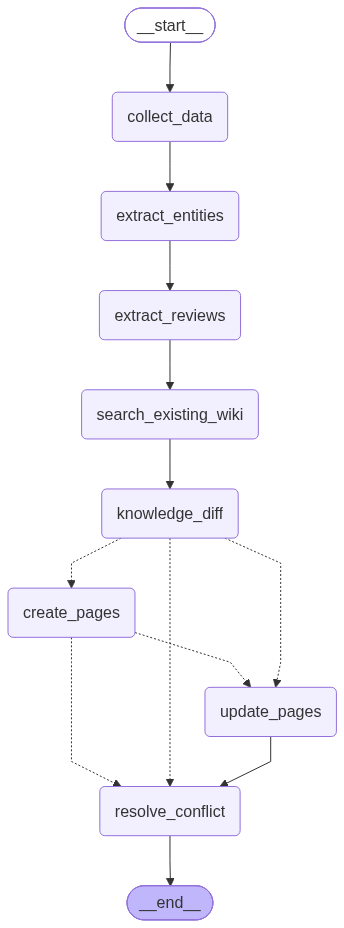

In [20]:
graph_builder = StateGraph(WikiState)

# nodes
graph_builder.add_node("collect_data", collect_data)
graph_builder.add_node("extract_entities", extract_entities)
graph_builder.add_node("extract_reviews", extract_reviews)
graph_builder.add_node("search_existing_wiki", search_existing_wiki)
graph_builder.add_node("knowledge_diff", knowledge_diff)
graph_builder.add_node("create_pages", create_pages)
graph_builder.add_node("update_pages", update_pages)
graph_builder.add_node("resolve_conflict", resolve_conflict)


# edges
graph_builder.add_edge(START, "collect_data")
graph_builder.add_edge("collect_data", "extract_entities")
graph_builder.add_edge("extract_entities", "extract_reviews")
graph_builder.add_edge("extract_reviews", "search_existing_wiki")
graph_builder.add_edge("search_existing_wiki", "knowledge_diff")
graph_builder.add_conditional_edges(
    "knowledge_diff",
     _route_after_diff , 
    {
       "create_pages": "create_pages",
       "update_pages": "update_pages",
       "resolve_conflict": "resolve_conflict"
    }
)

graph_builder.add_conditional_edges(
    "create_pages",
    _route_after_create,
    {
        "update_pages" : "update_pages",
        "resolve_conflict": "resolve_conflict"
    }
)
graph_builder.add_edge("update_pages", "resolve_conflict")
# graph.add_conditional_edges("merchant_llm", tools_condition)
# graph.add_edge("tools", "merchant_llm")


workflow = graph_builder.compile()
workflow

In [21]:
from pathlib import Path
def list_wiki_pages(wiki_dir: str, section: str) -> dict[str, str]:
    """
    List all .md pages in a wiki section.
    Returns dict of slug -> file_path.
    """
    pages = {}
    section_dir = Path(wiki_dir) / section
    if not section_dir.exists():
        return pages

    for md_file in section_dir.rglob("*.md"):
        if md_file.name in ("index.md", "log.md"):
            continue
        slug = md_file.stem
        pages[slug] = str(md_file)
    return pages

In [22]:
res = list_wiki_pages(r"C:\Users\ps302\OneDrive\Desktop\Razorpay\backend\merchant_knowledge\wiki", "knowledge")

In [23]:
for item in res:
    print(res)

{'headphones': 'C:\\Users\\ps302\\OneDrive\\Desktop\\Razorpay\\backend\\merchant_knowledge\\wiki\\knowledge\\categories\\headphones.md', 'smartphones': 'C:\\Users\\ps302\\OneDrive\\Desktop\\Razorpay\\backend\\merchant_knowledge\\wiki\\knowledge\\categories\\smartphones.md', 'tablets': 'C:\\Users\\ps302\\OneDrive\\Desktop\\Razorpay\\backend\\merchant_knowledge\\wiki\\knowledge\\categories\\tablets.md', 'apple-airpods-pro-2': 'C:\\Users\\ps302\\OneDrive\\Desktop\\Razorpay\\backend\\merchant_knowledge\\wiki\\knowledge\\products\\apple-airpods-pro-2.md', 'ipad-air-m2': 'C:\\Users\\ps302\\OneDrive\\Desktop\\Razorpay\\backend\\merchant_knowledge\\wiki\\knowledge\\products\\ipad-air-m2.md', 'iphone-15-pro': 'C:\\Users\\ps302\\OneDrive\\Desktop\\Razorpay\\backend\\merchant_knowledge\\wiki\\knowledge\\products\\iphone-15-pro.md', 'iphone-15': 'C:\\Users\\ps302\\OneDrive\\Desktop\\Razorpay\\backend\\merchant_knowledge\\wiki\\knowledge\\products\\iphone-15.md', 'oneplus-12': 'C:\\Users\\ps302\\On

In [24]:
#  tool binding to the llm
# llm_with_tools = llm.bind_tools(tools)

In [25]:
# Prompt
SYSTEM_PROMPT = """
You are the Merchant Commerce Agent.

You are responsible for handling customer shopping requests.

You have access to commerce tools.

Rules:

1. Never claim that a product was added unless add_to_cart
   successfully confirms it.

2. Never directly modify the cart yourself.

3. Use get_cart when you need current cart information.

4. Use get_upsell_products when the customer asks for
   recommendations or when an appropriate complementary
   product can be suggested.

5. Do not invent products.

6. Keep responses concise and commerce-focused.

7. If a tool fails, clearly tell the customer that the
   requested operation could not be completed.

8. MUST: Do not add the item to the cart until and unless customer ask to do, if he is asking about the product just tell it  where you have or not,
    and then ask him if he would like it to be added to the cart and along with it recommend the items that this inventory have
"""

In [26]:
# class CommerceState(TypedDict):

#     messages: Annotated[ list, add_messages ]

# """ later add ons
# user_id
# merchant_id
# cart
# payment_context
# policy_context
# """

In [27]:
# def merchant_llm_node(state: CommerceState):

#     messages = state["messages"]

#     system_message = {
#         "role": "system",
#         "content": SYSTEM_PROMPT
#     }

#     response = llm_with_tools.invoke(
#         [system_message] + messages
#     )

#     return {
#         "messages": [response]
#     }

    

In [28]:
# tool_node = ToolNode(tools)

In [29]:
# graph = StateGraph(CommerceState)

# # nodes
# graph.add_node("merchant_llm", merchant_llm_node )
# graph.add_node( "tools", tool_node )

# # edges
# graph.add_edge(START, "merchant_llm" )
# graph.add_conditional_edges("merchant_llm", tools_condition)
# graph.add_edge("tools", "merchant_llm")


# workflow = graph.compile()

In [30]:
class WikiState(TypedDict):
    """
    Central state that flows through all LangGraph nodes.

    Both 'knowledge' and 'marketing' sections use this same state.
    The `wiki_section` field controls which sub-directory is targeted.
    """

  

     # slug -> file_path
    # pages_to_create: list[WikiPage]
    

    # # ── Output ──
    # generated_pages: list[WikiPage]
    # index_updates: list[dict[str, str]]
    # log_entry: LogEntry
    # validation_result: ValidationResult

    # # ── Control ──
    # validation_errors: list[str]
    # status: str  # running | success | failed
    # error: str
